# Explore Saved Results

Use [run_broadcast.ipynb](run_broadcast.ipynb) to plan, launch, collect and plot hardware campaigns or repeat the restored Monte Carlo convergence study. This notebook provides additional saved-data exploration. Historical data and campaign results load together; figures save only as PNG. See [README](README.md) for setup and interpretation.


## Manuscript figures

Run the following cell **on its own** from the project root. It reads the saved data, displays the five data figures, and exports them in the order of the manuscript: **1** convergence, **2** memory benchmark, **4** QEC crossover, **5** delay fidelity, **6** hardware scaling. **Figure 3** is the Qiskit circuit, retained as `manuscript/m1n2qec0_circ.png`.

Edit `QISKIT_PALETTE`, `PLOT_RC`, `EXPORT`, and `FIGURE_1`, `FIGURE_2`, `FIGURE_4`, `FIGURE_5`, `FIGURE_6` at the top, then rerun. The palette is sampled directly from the Qiskit circuit: burgundy `#9F1853`, cyan `#33B1FF`, coral `#FA4D56`, and slate `#778899`. Receiver 1 uses burgundy and Receiver 2 cyan throughout the receiver plots. Sizes, fonts, colors, markers, line styles and opacity, axes, grids, legends, the crossover inset, delay confidence bands, scaling offsets/ranges, and the convergence reference are exposed; the plotting code is in the same cell for further changes.

Figure 1 overlays separate Receiver 1, Receiver 2, and Total lines for seeds 0–4. Its four-entry legend contains the reference and those three quantities; the reference is anchored to the first seed-0 total error. Figure 5 overlays all four selected Marrakesh sweeps on the left and shows Kingston on the right. Each panel has a Receiver 1, Receiver 2, and Mean legend, with its backend label inside the top-right corner. Each run has separate receiver and mean lines without markers. Every delay run/phase and scaling observation stays separate. Optional delay bands are conditional 95% Wilson shot intervals; scaling bars span receiver minimum–maximum and are not confidence intervals.

`SAVE_MANUSCRIPT_FIGURES = True` exports the five numbered PNG files into both `manuscript/` and `figures/`, plus source hashes and plotting settings in `figures/manuscript_sources.json`. Set it to `False` to preview. The manuscript references these filenames; rebuild `manuscript/apstemplate.tex` after exporting. If you change source selections or statistical displays, revise the corresponding captions too. The exploratory CLI uses different filenames.

Figure objects remain available in `manuscript_figures`, keyed by their manuscript numbers. Source selections use local paths; the complete result bundles are needed to reproduce these plots on another machine.


Figure 1: manuscript/figure_01_sampling_convergence.png
Figure 1: figures/figure_01_sampling_convergence.png
Figure 2: manuscript/figure_02_qec_memory.png


Figure 2: figures/figure_02_qec_memory.png
Figure 4: manuscript/figure_04_qec_crossover.png
Figure 4: figures/figure_04_qec_crossover.png


Figure 5: manuscript/figure_05_delay_repeats.png
Figure 5: figures/figure_05_delay_repeats.png


Figure 6: manuscript/figure_06_hardware_scaling.png
Figure 6: figures/figure_06_hardware_scaling.png
Figure 1


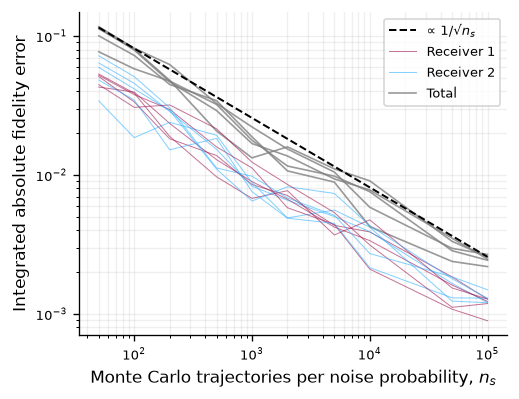

Figure 2


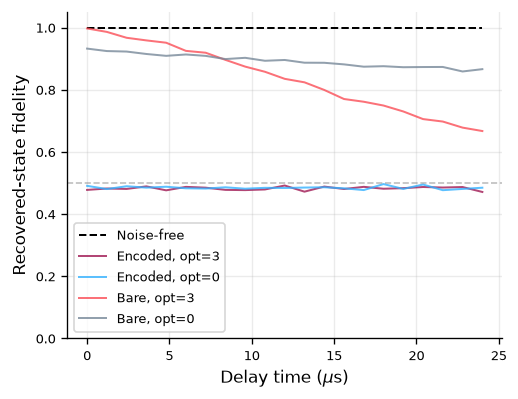

Figure 4


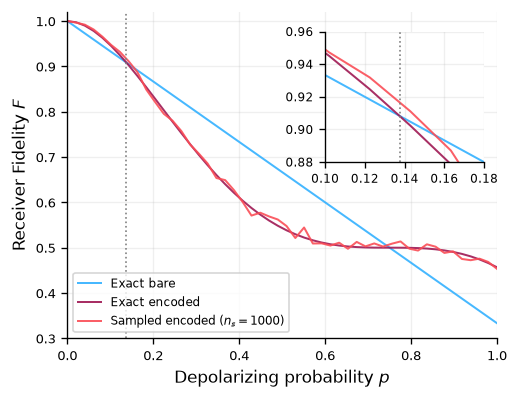

Figure 5


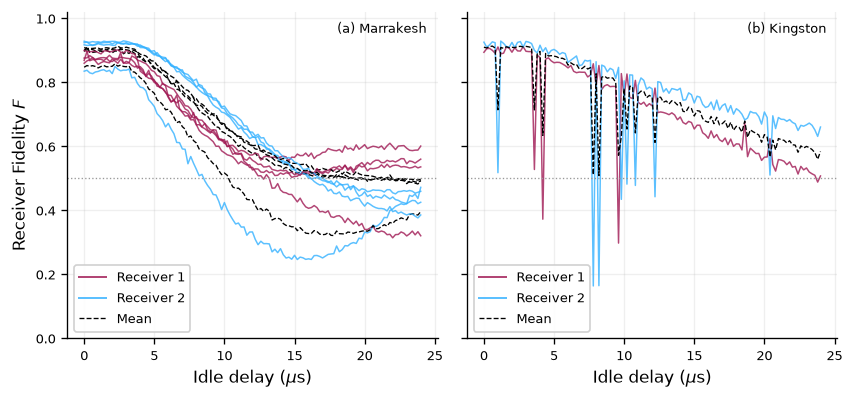

Figure 6


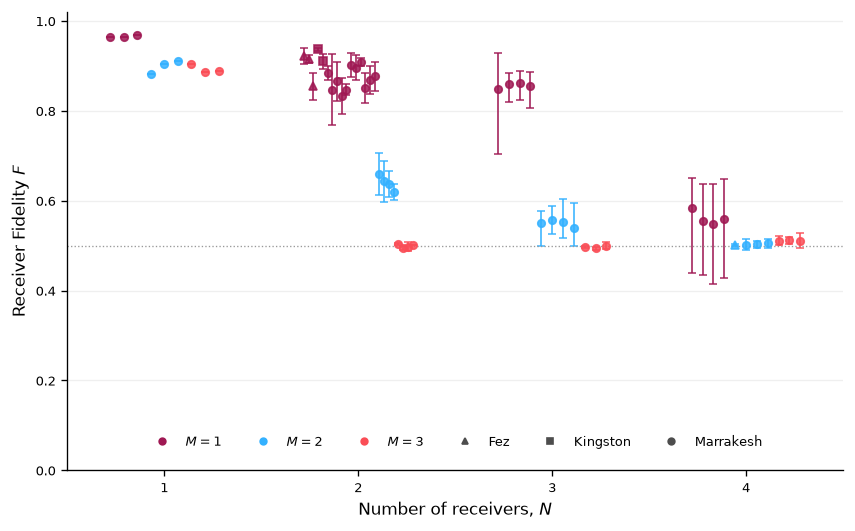

Figure 5: 5 delay sweeps across 2 backend panels; Figure 6: 55 separate observations; Figure 1: seed 0 plus seeds [1, 2, 3, 4].


In [1]:
# Run this cell on its own. Edit the settings below, then rerun to update all five data figures.
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from IPython.display import display

from broadcasting.analysis import delay_axis, joint_success_statistics, wilson_interval
from broadcasting.convergence import load_historical_convergence
from broadcasting.plotting import hardware_scaling_points, save_figure
from broadcasting.results import load_run
from broadcasting.simulation import logical_error_polynomial
from broadcasting.validation import dedupe_by_job
from scripts.analyze_saved_hardware import load_hardware_runs
from scripts.figure_sources import load_source, source_manifest

ROOT = Path.cwd().resolve()
if not (ROOT / "broadcasting").is_dir():
    raise RuntimeError("Run this cell from the Broadcasting project root.")

# -------------------------- EDIT PLOTTING SETTINGS HERE --------------------------
SAVE_MANUSCRIPT_FIGURES = True  # False previews without changing exported files.
OUTPUT_DIRS = [ROOT / "manuscript", ROOT / "figures"]
PROVENANCE_PATH = ROOT / "figures" / "manuscript_sources.json"
EXPORT = dict(dpi=300, bbox_inches="tight", pad_inches=0.06,
              facecolor="white", transparent=False, strip_titles=True)
# Any Matplotlib rcParam can be added here. Changes stay local to this cell.
PLOT_RC = {
    "figure.dpi": 120, "font.family": "DejaVu Sans", "font.size": 9,
    "axes.labelsize": 10, "axes.titlesize": 10, "axes.linewidth": 0.8,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "lines.linewidth": 1.2, "lines.markersize": 4,
    "axes.spines.top": False, "axes.spines.right": False,
}
# Sampled from the solid pixels in the Qiskit circuit (manuscript Figure 3).
# Edit these colors once to recolor every data plot; per-figure styles can override them.
QISKIT_PALETTE = {
    "burgundy": "#9F1853", "cyan": "#33B1FF", "coral": "#FA4D56", "slate": "#778899",
}
FIGURE_1 = {
    "filename": "figure_01_sampling_convergence.png", "figsize": (4.4, 3.4),
    "archive_dir": "results/convergence", "batches": ["repeats_01", "repeats_02"], "seeds": [1, 2, 3, 4],
    "show_seed_zero": True,
    # Apply the same component colors to every seed, including seed 0.
    "line_style": dict(linestyle="-", marker="", linewidth=0.6, alpha=0.6),
    "receiver_styles": [dict(color=QISKIT_PALETTE["burgundy"], label="Receiver 1"),
                        dict(color=QISKIT_PALETTE["cyan"], label="Receiver 2")],
    "total_style": dict(color="grey", label="Total", alpha=0.8, linewidth=1.0),
    "show_reference": True, "reference_exponent": -0.5,
    "reference_anchor_index": 0, "reference_multiplier": 1.0,
    "reference_style": dict(color="black", linestyle="--", marker="", linewidth=1.2, alpha=1,
                            label="∝ 1/√$n_s$"),
    "axes": dict(xlabel="Monte Carlo trajectories per noise probability, $n_s$",
                 ylabel="Integrated absolute fidelity error",
                 xlim=None, ylim=None, xscale="log", yscale="log"),
    "grid": dict(visible=True, which="both", alpha=0.2),
    "legend": dict(loc="best", fontsize=8, frameon=True),
    "layout": dict(pad=1.1),
}
FIGURE_2 = {
    "filename": "figure_02_qec_memory.png", "figsize": (4.4, 3.4),
    # Ordered: encoded opt3, encoded opt0, bare opt3, bare opt0.
    "sources": ["results/qec513/qec513_delay_sweep_20260513_123922.json",
                "results/qec513/qec513_delay_sweep_20260513_163257.json",
                "results/qec513/qec513_delay_sweep_20260518_132249.json",
                "results/qec513/qec513_delay_sweep_20260618_104151.json"],
    "data_styles": [dict(color=QISKIT_PALETTE["burgundy"], label="Encoded, opt=3"),
                    dict(color=QISKIT_PALETTE["cyan"], label="Encoded, opt=0"),
                    dict(color=QISKIT_PALETTE["coral"], label="Bare, opt=3"),
                    dict(color=QISKIT_PALETTE["slate"], label="Bare, opt=0")],
    "data_common": dict(linestyle="-", marker="", linewidth=1.2, alpha=0.8),
    "show_ideal": True,
    "ideal_style": dict(color="black", linestyle="--", marker="", linewidth=1.2, label="Noise-free"),
    "baseline": 0.5, "baseline_style": dict(color="gray", linestyle="--", linewidth=1, alpha=0.5),
    "xlabel": None,  # None uses the supported physical delay unit.
    "axes": dict(ylabel="Recovered-state fidelity", xlim=None, ylim=(0, 1.05),
                 xscale="linear", yscale="linear"),
    "grid": dict(visible=True, alpha=0.25),
    "legend": dict(loc="best", fontsize=8, frameon=True),
    "layout": dict(pad=1.1),
}
FIGURE_4 = {
    "filename": "figure_04_qec_crossover.png", "figsize": (4.4, 3.4),
    # Ordered: exact bare, exact encoded, sampled encoded. Each retains its native p grid.
    "sources": ["results/run_20260422_110316.json", "results/run_20260426_170827.json",
                "results/run_20260427_114317.json"],
    "theory_p_range": (0, 1), "theory_points": 500,
    # "bare_theory": dict(color="black", linestyle="--", linewidth=1.1, label="Bare theory"),
    # "encoded_theory": dict(color=QISKIT_PALETTE["burgundy"], linestyle="-", linewidth=1.3, label="Encoded theory"),
    "data_styles": [dict(marker="", color=QISKIT_PALETTE["cyan"], label="Exact bare"),
                    dict(marker="", color=QISKIT_PALETTE["burgundy"], label="Exact encoded"),
                    dict(marker="", color=QISKIT_PALETTE["coral"], label="Sampled encoded ($n_s={n_samples}$)")],
    "data_common": dict(linestyle="-", markersize=3.5, alpha=0.9),
    "show_crossover": True, "crossover_style": dict(color="0.5", linestyle=":", linewidth=1),
    "show_inset": True, "inset_bounds": [0.60, 0.54, 0.37, 0.40],
    "inset_axes": dict(xlim=(0.1, 0.18), ylim=(0.88, 0.96)),
    "inset_ticks": dict(axis="both", labelsize=7),
    "axes": dict(xlabel="Depolarizing probability $p$", ylabel="Receiver Fidelity $F$",
                xlim=(0, 1), ylim=(0.3, 1.02), xscale="linear", yscale="linear"),
    "grid": dict(visible=True, alpha=0.2),
    "legend": dict(loc="lower left", fontsize=7, frameon=True),
    "layout": dict(pad=1.1),
}
FIGURE_5 = {
    "filename": "figure_05_delay_repeats.png", "panel_backends": ["ibm_marrakesh", "ibm_kingston"],
    "panel_size": (3.6, 3.4),
    "sharey": True,
    # Five 121-point opt3 sweeps: one Kingston and four Marrakesh runs.
    "sources": ["results/run_20260518_120232.json", "results/run_20260908_153150_79eab41b.json",
                "campaigns/delay_01/results/repeat_000_m1_n2.json",
                "campaigns/delay_01/results/repeat_001_m1_n2.json",
                "campaigns/delay_01/results/repeat_002_m1_n2.json"],
    "receiver_colors": [QISKIT_PALETTE["burgundy"], QISKIT_PALETTE["cyan"]],
    "receiver_style": dict(marker="", linewidth=0.9, alpha=0.8),
    # Styles are assigned within each backend panel, in source-list order.
    "run_styles": [dict(linestyle="-"), dict(linestyle="-"),
                   dict(linestyle="-"), dict(linestyle="-")],
    "receiver_label": "Receiver {receiver}",
    "show_intervals": False, "confidence": 0.95, "interval_style": dict(alpha=0.18, linewidth=0),
    "show_mean": True, "mean_style": dict(color="black", marker="", linewidth=0.8, alpha=1, label="Mean", linestyle="--"),
    "baseline": 0.5, "baseline_style": dict(color="0.6", marker="", linestyle=":", linewidth=0.8, alpha=1),
    # None uses the archived dt conversion (microseconds), or native dt if unknown.
    "xlabel": None,
    "axes": dict(ylabel="Receiver Fidelity $F$", xlim=None, ylim=(0, 1.02), xscale="linear", yscale="linear"),
    "panel_label": "({letter}) {backend}",
    "panel_text": dict(x=0.97, y=0.97, fontsize=8, va="top", ha="right"),
    "grid": dict(visible=True, alpha=0.2),
    "legend": dict(loc="lower left", ncol=1, frameon=True, framealpha=0.9, fontsize=8),
    "layout": dict(pad=1.1, w_pad=1.2),
}
FIGURE_6 = {
    "filename": "figure_06_hardware_scaling.png", "figsize": (7.2, 4.5),
    "source_dirs": ["results", "campaigns/scaling_01/results", "campaigns/delay_01/results"],
    # Optional exact filepath selection; None keeps every eligible opt3 tau=0 observation.
    "sources": None,
    "sender_colors": {1: QISKIT_PALETTE["burgundy"], 2: QISKIT_PALETTE["cyan"], 3: QISKIT_PALETTE["coral"]},
    "backend_markers": {"ibm_kingston": "s", "ibm_fez": "^", "ibm_marrakesh": "o"},
    "fallback_colors": [QISKIT_PALETTE["slate"], QISKIT_PALETTE["coral"], QISKIT_PALETTE["cyan"]],
    "fallback_markers": ["D", "v", "P", "X"],
    "horizontal_spread": 0.56,  # Full width around each integer N; zero disables offsets.
    "show_receiver_range": True,
    "point_style": dict(markersize=4.5, capsize=2.5, linewidth=1.1, alpha=0.85, linestyle="none"),
    "sender_label": "$M={sender}$", "backend_label": "{backend}",
    "backend_legend_color": "0.3",
    "baseline": 0.5, "baseline_style": dict(color="0.6", linestyle=":", linewidth=0.8),
    "axes": dict(xlabel="Number of receivers, $N$", ylabel="Receiver Fidelity $F$",
                 xlim=None, ylim=(0, 1.02), xscale="linear", yscale="linear"),
    "xticks": None,  # None uses the integer receiver counts.
    "grid": dict(visible=True, axis="y", alpha=0.2),
    "legend": dict(loc="lower center", bbox_to_anchor=(0.5, 0.02), ncol=6, frameon=False, fontsize=8),
    "layout": dict(pad=1.1),
}
# ------------------------- RENDER FROM SAVED DATA ONLY -------------------------
# Plotting code is also in this cell for changes beyond the settings above.
_manifest = source_manifest()

def _read_figure_run(relative_path):
    return (load_source(relative_path, manifest=_manifest) if relative_path in _manifest["runs"]
            else load_run(ROOT / relative_path))

def _style_axis(ax, settings):
    properties = dict(settings["axes"])
    # Set scales before limits; passing None limits would disable autoscaling.
    ax.set_xscale(properties.pop("xscale", "linear"))
    ax.set_yscale(properties.pop("yscale", "linear"))
    ax.set(**{key: value for key, value in properties.items() if value is not None})
    ax.grid(**settings["grid"])

def _source_evidence(path):
    path = Path(path).resolve()
    relative = str(path.relative_to(ROOT)) if path.is_relative_to(ROOT) else str(path)
    return {"path": relative, "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
            "historical_overrides": _manifest["runs"].get(relative, {}).get("historical_overrides", {})}

# Close only this cell's previous figures when rerunning.
for _old_figure in globals().get("manuscript_figures", {}).values():
    plt.close(_old_figure)
manuscript_figures = {}
manuscript_sources = {}

with plt.rc_context(PLOT_RC):
    # Figure 1: receiver errors and their total for each saved seed, without pooling.
    cfg = FIGURE_1
    study = load_historical_convergence(archive_dir=ROOT / cfg["archive_dir"])
    repetitions = [rep for rep in study.repetitions
                   if (cfg["batches"] is None or rep["batch"] in cfg["batches"])
                   and (cfg["seeds"] is None or rep["seed"] in cfg["seeds"])]
    if cfg["seeds"] is not None and set(cfg["seeds"]) - {rep["seed"] for rep in repetitions}:
        raise ValueError("Selected convergence seeds are missing from the selected archive/batches.")
    fig1, ax1 = plt.subplots(figsize=cfg["figsize"])
    counts = np.asarray(study.sample_counts)
    historical_per_receiver = np.asarray(study.historical["errors_per_receiver"])
    historical = historical_per_receiver.sum(axis=1)
    component_styles = [*cfg["receiver_styles"], cfg["total_style"]]

    def _plot_convergence_components(x, errors, identity):
        errors = np.asarray(errors)
        if errors.shape != (len(x), 2) or len(cfg["receiver_styles"]) != 2:
            raise ValueError("Figure 1 requires two receiver errors at every saved sample count.")
        components = [errors[:, 0], errors[:, 1], errors.sum(axis=1)]
        for y, component_style in zip(components, component_styles):
            keep = y > 0 if cfg["axes"]["yscale"] == "log" else np.ones(len(y), dtype=bool)
            if not np.all(keep):
                print(f"Figure 1: omitted {np.sum(~keep)} zero-error point(s) on logarithmic y axis "
                      f"for {identity}, {component_style['label']}.")
            # Legend entries describe quantities; every seed remains a separate line.
            style = {**cfg["line_style"], **component_style, "label": "_nolegend_"}
            ax1.plot(np.asarray(x)[keep], y[keep], **style)

    convergence_paths = set()
    if cfg["show_seed_zero"] or cfg["show_reference"]:
        convergence_paths.add(ROOT / "analysis/convergence/historical_summary.json")
    if cfg["show_seed_zero"]:
        _plot_convergence_components(counts, historical_per_receiver, f"seed {study.config.seed}")
    for repetition in repetitions:
        points = repetition["points"]
        x = np.asarray([point["n_samples"] for point in points])
        errors = np.asarray([point["errors_per_receiver"] for point in points])
        _plot_convergence_components(x, errors, f"seed {repetition['seed']} ({repetition['batch']})")
        if not repetition["complete"]:
            print(f"Figure 1: seed {repetition['seed']} ({repetition['batch']}) is partial: {len(points)} saved counts.")
        convergence_paths.update(Path(point["path"]) for point in points)
        batch = study.archive_dir / repetition["batch"]
        convergence_paths.update([batch / "study.json", batch / "exact.json"])
    convergence_handles = []
    if cfg["show_reference"]:
        anchor = cfg["reference_anchor_index"]
        reference = cfg["reference_multiplier"] * historical[anchor] * (counts / counts[anchor]) ** cfg["reference_exponent"]
        reference_line, = ax1.plot(counts, reference, **cfg["reference_style"])
        convergence_handles.append(reference_line)
    convergence_handles.extend(Line2D([], [], **{**cfg["line_style"], **style}) for style in component_styles)
    _style_axis(ax1, cfg)
    ax1.legend(handles=convergence_handles, **cfg["legend"])
    fig1.tight_layout(**cfg["layout"])
    manuscript_figures[1] = fig1
    manuscript_sources[1] = [_source_evidence(path) for path in sorted(convergence_paths)]

    # Figure 2: standalone memory benchmark, retaining each source's native delay grid.
    cfg = FIGURE_2
    memory_runs = [_read_figure_run(path) for path in cfg["sources"]]
    if not memory_runs or len(memory_runs) != len(cfg["data_styles"]):
        raise ValueError("Figure 2 needs one data style for each memory source.")
    fig2, ax2 = plt.subplots(figsize=cfg["figsize"])
    scale, unit = delay_axis(memory_runs[0])
    if cfg["show_ideal"]:
        ax2.plot(scale * np.asarray(memory_runs[0]["tau_values"]),
                 memory_runs[0]["ideal_fidelities"], **cfg["ideal_style"])
    for run, style in zip(memory_runs, cfg["data_styles"]):
        run_scale, run_unit = delay_axis(run)
        if run_unit != unit:
            raise ValueError("Figure 2 memory curves must use a common supported delay unit.")
        ax2.plot(run_scale * np.asarray(run["tau_values"]), run["backend_fidelities"],
                 **{**cfg["data_common"], **style})
    if cfg["baseline"] is not None:
        ax2.axhline(cfg["baseline"], **cfg["baseline_style"])
    _style_axis(ax2, cfg)
    ax2.set_xlabel(cfg["xlabel"] or (r"Delay time ($\mu$s)" if unit == "us" else "Delay time (dt)"))
    ax2.legend(**cfg["legend"])
    fig2.tight_layout(**cfg["layout"])
    manuscript_figures[2] = fig2
    manuscript_sources[2] = [_source_evidence(ROOT / path) for path in cfg["sources"]]

    # Figure 4: exact and sampled crossover curves on their own saved grids.
    cfg = FIGURE_4
    crossover_runs = [_read_figure_run(path) for path in cfg["sources"]]
    if len(crossover_runs) != 3 or len(cfg["data_styles"]) != 3:
        raise ValueError("Figure 4 needs exact bare, exact encoded, and sampled encoded sources/styles.")
    for run, qec, backend in zip(crossover_runs, [False, True, True], ["aer_exact", "aer_exact", "aer_sampling"]):
        if ((run["M"], run["N"], run["sweep"]["axis"]) != (1, 2, "p")
                or run["use_qec"] != qec or run["backend"] != backend
                or not np.isclose(run["alpha"], crossover_runs[0]["alpha"])
                or not np.allclose(run["theta_samples"], crossover_runs[0]["theta_samples"])):
            raise ValueError("Figure 4 sources must have matching protocol/target settings and the stated simulation modes.")
    fig4, ax4 = plt.subplots(figsize=cfg["figsize"])
    inset4 = ax4.inset_axes(cfg["inset_bounds"]) if cfg["show_inset"] else None
    p = np.linspace(*cfg["theory_p_range"], cfg["theory_points"])
    for ax in [ax4] + ([inset4] if inset4 is not None else []):
        # ax.plot(p, 1 - 2 * p / 3, **cfg["bare_theory"])
        # ax.plot(p, 1 - 2 * logical_error_polynomial(p) / 3, **cfg["encoded_theory"])
        for run, style in zip(crossover_runs, cfg["data_styles"]):
            style = {**cfg["data_common"], **style}
            style["label"] = style["label"].replace("{n_samples}", str(run.get("n_samples")))
            ax.plot(run["sweep"]["values"], np.asarray(run["fidelities"]).mean(axis=1), **style)
        if cfg["show_crossover"]:
            ax.axvline((3 - np.sqrt(6)) / 4, **cfg["crossover_style"])
        ax.grid(**cfg["grid"])
    _style_axis(ax4, cfg)
    if inset4 is not None:
        inset4.set(**cfg["inset_axes"])
        inset4.tick_params(**cfg["inset_ticks"])
    ax4.legend(**cfg["legend"])
    fig4.tight_layout(**cfg["layout"])
    manuscript_figures[4] = fig4
    manuscript_sources[4] = [_source_evidence(ROOT / path) for path in cfg["sources"]]

    # Figure 5: overlay each backend's saved sweeps in its own panel.
    cfg = FIGURE_5
    delay_runs = dedupe_by_job([_read_figure_run(path) for path in cfg["sources"]])
    traces = []
    for run in delay_runs:
        if (run["experiment_type"] != "hardware" or run.get("optimization_level") != 3
                or (run["M"], run["N"]) != (1, 2) or run.get("use_qec")
                or run["sweep"]["axis"] != "tau" or len(run["sweep"]["values"]) < 2 or not run.get("counts")):
            raise ValueError(f"Figure 5 needs unencoded opt3 M=1,N=2 delay records with counts: {run['filename']}")
        traces.extend((run, i, row) for i, row in enumerate(run["counts"]))
    panel_backends = cfg["panel_backends"]
    if len(panel_backends) != 2 or set(panel_backends) != {run["backend"] for run in delay_runs}:
        raise ValueError("Figure 5 needs two backend panels covering every selected source.")
    panel_traces = [[trace for trace in traces if trace[0]["backend"] == backend]
                    for backend in panel_backends]
    if not cfg["run_styles"] or any(len(group) > len(cfg["run_styles"]) for group in panel_traces):
        raise ValueError("Add a distinct run_style for every overlaid sweep in the largest panel.")
    fig5, axes5 = plt.subplots(1, 2, squeeze=False, sharey=cfg["sharey"],
                              figsize=(2 * cfg["panel_size"][0], cfg["panel_size"][1]))
    for panel_index, (ax, backend, group) in enumerate(zip(axes5.flat, panel_backends, panel_traces)):
        if len({delay_axis(run)[1] for run, _, _ in group}) != 1:
            raise ValueError(f"Cannot overlay known physical times and unknown native dt for {backend}.")
        for run_index, (run, theta_index, counts) in enumerate(group):
            run_style = cfg["run_styles"][run_index]
            scale, unit = delay_axis(run)
            order = np.argsort(run["sweep"]["values"])
            tau = scale * np.asarray(run["sweep"]["values"])[order]
            stats = [joint_success_statistics(counts[i], run["N"]) for i in order]
            local = np.asarray([item["local_fidelities"] for item in stats])
            for receiver in range(run["N"]):
                color = cfg["receiver_colors"][receiver % len(cfg["receiver_colors"])]
                ax.plot(tau, local[:, receiver], color=color,
                        label=cfg["receiver_label"].format(receiver=receiver + 1),
                        **{**cfg["receiver_style"], **run_style})
                if cfg["show_intervals"]:
                    ci = np.asarray([wilson_interval(item["local_fidelities"][receiver] * item["shots"],
                                                    item["shots"], cfg["confidence"]) for item in stats])
                    ax.fill_between(tau, ci[:, 0], ci[:, 1], color=color, **cfg["interval_style"])
            if cfg["show_mean"]:
                ax.plot(tau, local.mean(axis=1), **{**run_style, **cfg["mean_style"], "marker": ""})
        if cfg["baseline"] is not None:
            ax.axhline(cfg["baseline"], **cfg["baseline_style"])
        label = cfg["panel_label"].format(letter=chr(97 + panel_index), backend=backend.removeprefix("ibm_").title())
        ax.text(s=label, transform=ax.transAxes, **cfg["panel_text"])
        _style_axis(ax, cfg)
        if panel_index > 0:
            ax.set_ylabel("")
        ax.set_xlabel(cfg["xlabel"] or (r"Idle delay ($\mu$s)" if unit == "us" else "Idle delay (dt)"))
    receiver_handles = [Line2D([], [], color=color, linestyle="-", marker="", alpha=cfg["receiver_style"]["alpha"],
                               label=cfg["receiver_label"].format(receiver=i + 1))
                        for i, color in enumerate(cfg["receiver_colors"][:2])]
    if cfg["show_mean"]:
        receiver_handles.append(Line2D([], [], **cfg["mean_style"]))
    for ax in axes5.flat:
        ax.legend(handles=receiver_handles, **cfg["legend"])
    fig5.tight_layout(**cfg["layout"])
    manuscript_figures[5] = fig5
    manuscript_sources[5] = [_source_evidence(run["filepath"]) for run in delay_runs]

    # Figure 6: one point per observation; the range is across receivers, not repeats.
    cfg = FIGURE_6
    scaling_runs = ([_read_figure_run(path) for path in cfg["sources"]] if cfg["sources"] is not None
                    else load_hardware_runs(*(ROOT / path for path in cfg["source_dirs"])))
    scaling_runs = [run for run in scaling_runs if not run.get("use_qec")]
    scaling_points = hardware_scaling_points(scaling_runs)
    if not scaling_points:
        raise ValueError("No saved opt3 zero-delay observations for Figure 6.")
    senders = sorted({point["M"] for point in scaling_points})
    backends = sorted({point["backend"] for point in scaling_points})
    receivers = sorted({point["N"] for point in scaling_points})
    colors = {m: cfg["sender_colors"].get(m, cfg["fallback_colors"][i % len(cfg["fallback_colors"])])
              for i, m in enumerate(senders)}
    markers = {b: cfg["backend_markers"].get(b, cfg["fallback_markers"][i % len(cfg["fallback_markers"])])
               for i, b in enumerate(backends)}
    fig6, ax6 = plt.subplots(figsize=cfg["figsize"])
    for n in receivers:
        group = [point for point in scaling_points if point["N"] == n]
        offsets = np.linspace(-cfg["horizontal_spread"] / 2, cfg["horizontal_spread"] / 2, len(group)) if len(group) > 1 else [0]
        for point, offset in zip(group, offsets):
            point["x"] = float(n + offset)
            mean = point["mean"]
            error = [[max(0, mean - point["minimum"])], [max(0, point["maximum"] - mean)]]
            ax6.errorbar(point["x"], mean, yerr=error if cfg["show_receiver_range"] else None,
                         marker=markers[point["backend"]], color=colors[point["M"]], **cfg["point_style"])
    handles = [Line2D([], [], color=colors[m], marker="o", linestyle="none",
                      label=cfg["sender_label"].format(sender=m)) for m in senders]
    handles += [Line2D([], [], color=cfg["backend_legend_color"], marker=markers[b], linestyle="none",
                       label=cfg["backend_label"].format(backend=b.removeprefix("ibm_").title())) for b in backends]
    ax6.legend(handles=handles, **cfg["legend"])
    _style_axis(ax6, cfg)
    ax6.set_xticks(cfg["xticks"] if cfg["xticks"] is not None else range(min(receivers), max(receivers) + 1))
    if cfg["axes"]["xlim"] is None:
        ax6.set_xlim(min(receivers) - 0.5, max(receivers) + 0.5)
    if cfg["baseline"] is not None:
        ax6.axhline(cfg["baseline"], **cfg["baseline_style"])
    fig6.tight_layout(**cfg["layout"])
    fig6.broadcasting_points = scaling_points
    manuscript_figures[6] = fig6
    eligible_runs = [run for run in dedupe_by_job(scaling_runs) if hardware_scaling_points([run])]
    manuscript_sources[6] = [_source_evidence(run["filepath"]) for run in eligible_runs]

    # Export only after all sources and all five plots succeeded.
    settings = {1: FIGURE_1, 2: FIGURE_2, 4: FIGURE_4, 5: FIGURE_5, 6: FIGURE_6}
    if SAVE_MANUSCRIPT_FIGURES:
        for number, fig in manuscript_figures.items():
            for directory in OUTPUT_DIRS:
                path = save_figure(fig, Path(directory) / settings[number]["filename"], **EXPORT)
                print(f"Figure {number}: {path.relative_to(ROOT) if path.is_relative_to(ROOT) else path}")
        provenance = {"schema_version": 1, "generator": "visualizations.ipynb#manuscript-figures",
                      "palette": QISKIT_PALETTE, "palette_source": _source_evidence(ROOT / "manuscript/m1n2qec0_circ.png"),
                      "rc_params": PLOT_RC, "export": EXPORT,
                      "figures": {str(n): {"settings": settings[n], "sources": manuscript_sources[n]}
                                  for n in settings},
                      "scaling_points": scaling_points}
        PROVENANCE_PATH.parent.mkdir(parents=True, exist_ok=True)
        PROVENANCE_PATH.write_text(json.dumps(provenance, indent=2) + "\n")
    for number, fig in manuscript_figures.items():
        print(f"Figure {number}")
        display(fig)
        plt.close(fig)

print(f"Figure 5: {len(traces)} delay sweeps across {len(panel_backends)} backend panels; Figure 6: {len(scaling_points)} separate observations; "
      f"Figure 1: seed {study.config.seed} plus seeds {[rep['seed'] for rep in repetitions]}.")
# Figures and data remain available as manuscript_figures, scaling_points, and study.


In [ ]:
from collections import defaultdict
from pathlib import Path
import itertools

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from qiskit.quantum_info import state_fidelity

from broadcasting import load_run, list_runs
from broadcasting.analysis import joint_success_statistics
from scripts.generate_figures import generate_qec_crossover
from scripts.analyze_saved_hardware import load_hardware_runs
from broadcasting.plotting import plot_3d_fidelity, plot_delay_repeats, plot_hardware_scaling, plot_run_sweep, save_figure
from broadcasting.simulation import run_broadcast_no_qec, run_broadcast_qec
from broadcasting.validation import dedupe_by_job, find_duplicate_jobs, group_by_cohort

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120})

ROOT = Path.cwd()
if not (ROOT / "broadcasting").is_dir():
    raise RuntimeError("Start Jupyter from the project directory.")
RESULTS_DIR = ROOT / "results"
CAMPAIGN_RESULTS_DIRS = []  # Add campaign roots outside results/ here.
FIGURE_DIR = Path("figures")
SAVE_FIGURES = False


## Load Runs


In [ ]:
all_roots = [RESULTS_DIR, *CAMPAIGN_RESULTS_DIRS]
hardware_runs = load_hardware_runs(*all_roots)
simulation_runs = [run for root in all_roots for run in list_runs(root)
                   if run["experiment_type"] == "simulation"]
runs = simulation_runs + hardware_runs
print(f"Found {len(runs)} run(s) in {RESULTS_DIR}/")
for i, run in enumerate(runs):
    sweep = run.get("sweep", {})
    qec = "QEC" if run.get("use_qec") else "no-QEC"
    opt = run.get("optimization_level")
    opt_text = f" opt={opt}" if opt is not None else ""
    print(
        f"[{i:>2}] {run['filename']}: M={run['M']} N={run['N']} {qec} "
        f"{run['experiment_type']}/{run.get('backend')}{opt_text} "
        f"{len(sweep.get('values', []))} {sweep.get('axis', '?')}-points"
    )


## Plot One Saved Run


In [ ]:
RUN_INDEX = -1

if not runs:
    print("No saved runs to plot.")
else:
    run = runs[RUN_INDEX]
    fig = plot_run_sweep(run, show=False)
    plt.tight_layout()
    if SAVE_FIGURES:
        save_figure(fig, FIGURE_DIR / f"{Path(run['filename']).stem}.png")
    plt.show()


## Compare Saved Delay Repeats

Each job, campaign case and random-angle sample has its own panel. Receiver curves use the archived dt conversion and marginal Wilson 95% shot intervals. Unknown time conversions remain in native dt. Phase samples and repeats are never averaged together.


In [ ]:
selected = [run for run in hardware_runs if run["optimization_level"] == 3
            and len(run["sweep"]["values"]) > 1]
# Narrow selected by campaign run_id, backend or filename if desired.
if not selected:
    print("No saved opt3 delay sweeps found.")
else:
    fig = plot_delay_repeats(selected)
    if SAVE_FIGURES:
        save_figure(fig, FIGURE_DIR / "selected_delay_repeats.png")
    plt.show()


## Opt3 Hardware Fidelity Versus Number Of Receivers

The x axis is receiver count N, the y axis is fidelity, and color identifies sender count M. Each point is one job/case/theta receiver mean; vertical bars span that observation’s receiver minimum and maximum. Backend marker shapes and small horizontal offsets keep observations separate. Bars show receiver spread, not shot uncertainty. Historical device and circuit differences remain visible; no pooled size trend is inferred.


In [ ]:
if not any(run["optimization_level"] == 3 and 0 in run["sweep"]["values"]
           for run in hardware_runs):
    print("No saved opt3 zero-delay hardware runs found.")
else:
    fig = plot_hardware_scaling(hardware_runs)
    if SAVE_FIGURES:
        save_figure(fig, FIGURE_DIR / "hardware_tau0_exploration.png")
    plt.show()
    # Full identities and coordinates for every plotted point.
    display(fig.broadcasting_points)


## QEC Crossover From Pinned Saved Simulation Runs

`figures/sources.json` selects matching M,N,alpha,theta runs explicitly. Each curve uses its own saved probability grid; the inset resolves the small-p crossover. No new simulations run here.


In [ ]:
# This helper reads pinned existing records and returns the figure when no output is requested.
fig = generate_qec_crossover([])
if SAVE_FIGURES:
    save_figure(fig, FIGURE_DIR / "qec_crossover_exploration.png")
plt.show()


## Exact Vs Sampling Groups


In [ ]:
groups = defaultdict(list)
for run in runs:
    if run["experiment_type"] == "simulation" and run.get("use_qec") and run.get("sweep", {}).get("axis") == "p":
        groups[(run["M"], run["N"])].append(run)

if not groups:
    print("No QEC simulation runs found.")
else:
    ncols = min(len(groups), 3)
    nrows = int(np.ceil(len(groups) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.2 * nrows), squeeze=False, sharey=True)

    for idx, ((M, N), group) in enumerate(sorted(groups.items())):
        ax = axes[idx // ncols][idx % ncols]
        for run in group:
            p = np.asarray(run["sweep"]["values"], dtype=float)
            avg = np.asarray(run["fidelities"], dtype=float).mean(axis=1)
            if run.get("backend") == "aer_exact":
                ax.plot(p, avg, color="tab:red", linewidth=1.8, label="exact")
            elif run.get("backend") == "aer_sampling":
                ax.plot(p, avg, "--", color="tab:blue", alpha=0.45, label=f"sampling {run.get('n_samples')}")
        ax.text(0.03, 0.05, f"M={M}, N={N}", transform=ax.transAxes, fontsize=9)
        ax.axhline(0.5, color="gray", linestyle=":", alpha=0.4)
        ax.set_xlabel("Depolarizing probability p")
        if idx % ncols == 0:
            ax.set_ylabel("Average fidelity")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.2)

    for idx in range(len(groups), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    plt.tight_layout()
    if SAVE_FIGURES:
        save_figure(fig, FIGURE_DIR / "exact_sampling_groups.png")
    plt.show()


## Pairwise Receiver Exploration

This cell contains optional pairwise-fidelity exploration. It is off by default because the QEC contour can be slow.


In [ ]:
RUN_PAIRWISE_SCATTER = False
RUN_PAIRWISE_CONTOUR = False

if RUN_PAIRWISE_SCATTER:
    M_pair, N_pair = 2, 3
    repetitions = 2
    outcomes = list(itertools.product(range(N_pair + 1), repeat=M_pair))
    results = []
    for _ in range(repetitions):
        for outcome in outcomes:
            p_list_pair = np.random.uniform(0.0, 1.0, N_pair)
            theta_pair = np.random.uniform(0.0, 2 * np.pi, M_pair)
            results.append(
                run_broadcast_qec(
                    M=M_pair,
                    N=N_pair,
                    alpha=1 / np.sqrt(2),
                    theta_list=theta_pair,
                    p_list=p_list_pair,
                    outcomes_list=outcome,
                )
            )

    n = len(results)
    points = np.zeros((3, 3 * n))
    for i, (fidelities, _, reduced_states) in enumerate(results):
        pairs = [(0, 1), (0, 2), (1, 2)]
        for j, (a, b) in enumerate(pairs):
            points[0, i + j * n] = fidelities[a]
            points[1, i + j * n] = fidelities[b]
            points[2, i + j * n] = state_fidelity(reduced_states[a], reduced_states[b])

    fig = plot_3d_fidelity(points, show=False)
    plt.tight_layout()
    if SAVE_FIGURES:
        save_figure(fig, FIGURE_DIR / "pairwise_receiver_scatter.png")
    plt.show()

if RUN_PAIRWISE_CONTOUR:
    M_c, N_c = 1, 2
    theta_c = [np.pi / 5]
    p_grid = np.linspace(0.0, 1.0, 18)
    outcomes = list(itertools.product(range(N_c + 1), repeat=M_c))

    def collect_points(use_qec):
        runner = run_broadcast_qec if use_qec else run_broadcast_no_qec
        F1, F2, F12 = [], [], []
        for p1 in p_grid:
            for p2 in p_grid:
                f1 = f2 = f12 = 0.0
                for outcome in outcomes:
                    fidelities, _, reduced = runner(
                        M=M_c,
                        N=N_c,
                        alpha=1 / np.sqrt(2),
                        theta_list=theta_c,
                        p_list=[p1, p2],
                        outcomes_list=outcome,
                    )
                    f1 += fidelities[0]
                    f2 += fidelities[1]
                    f12 += state_fidelity(reduced[0], reduced[1])
                denom = len(outcomes)
                F1.append(f1 / denom)
                F2.append(f2 / denom)
                F12.append(f12 / denom)
        return np.asarray(F1), np.asarray(F2), np.asarray(F12)

    datasets = [collect_points(False), collect_points(True)]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    for ax, (F1, F2, F12), label in zip(axes, datasets, ["No QEC", "QEC"]):
        tcf = ax.tricontourf(F1, F2, F12, levels=np.linspace(0, 1, 21), cmap=cm.magma, vmin=0, vmax=1)
        ax.text(0.03, 0.05, label, transform=ax.transAxes, color="white", fontsize=10)
        ax.set_xlabel("Fidelity(receiver 1, target)")
        ax.set_ylabel("Fidelity(receiver 2, target)")
        ax.set_xlim(0.5, 1.0)
        ax.set_ylim(0.5, 1.0)
        ax.set_aspect("equal")
        fig.colorbar(tcf, ax=ax, label="Fidelity(receiver 1, receiver 2)")
    plt.tight_layout()
    if SAVE_FIGURES:
        save_figure(fig, FIGURE_DIR / "pairwise_receiver_contours.png")
    plt.show()


## Joint/Global Fidelity And Receiver Covariance

Each histogram preserves joint receiver outcomes. The shared helper computes global fidelity, worst-receiver fidelity, receiver-success covariance and paired receiver asymmetry with finite-shot intervals without pooling theta samples or jobs. These intervals assume independent shots with fixed probabilities and do not include device drift. For every saved job/delay, run `scripts/analyze_saved_hardware.py`; its derived report is in `analysis/hardware/report.md`.


In [ ]:
RUN_FILENAME = None  # None -> first hardware run with counts
SWEEP_INDEX = 0
THETA_INDEX = 0

candidates = [
    run for run in runs
    if run["experiment_type"] == "hardware" and run.get("counts")
    and (RUN_FILENAME is None or run["filename"] == RUN_FILENAME)
]
if not candidates:
    print("No hardware run with saved joint counts found.")
else:
    run = candidates[0]
    stats = joint_success_statistics(run["counts"][THETA_INDEX][SWEEP_INDEX], run["N"])
    print(f"Run: {run['filename']}, theta={THETA_INDEX}, delay={run['sweep']['values'][SWEEP_INDEX]} dt")
    for key, value in stats.items():
        print(f"  {key}: {value}")
    print("Nonzero success covariance does not identify correlated physical noise; "
          "preparation, feedforward, readout and within-job drift can contribute. "
          "Zero covariance in one measurement basis also does not rule out correlated noise.")
